In [1]:
# ==========================================================
# PASO 1.4 — Caracterización temporal del precio de bolsa
# ==========================================================

# --- Celda A: Librerías ---
import pandas as pd               # dataframes y series de tiempo
import numpy as np                # numérico (lo usamos para percentiles más abajo)
import matplotlib.pyplot as plt   # gráficas base
import seaborn as sns             # gráficas estadísticas (boxplots) construidas sobre matplotlib

# Nota de compatibilidad: pandas + matplotlib + seaborn no tienen conflictos conocidos
# entre sí. El único cuidado real (ya lo vivimos con pydataxm) es no usar argumentos
# deprecados de pandas 3.0 como errors='ignore' — no aparecen en este código.

sns.set_theme(style="whitegrid")  # solo estética

In [2]:
import os
print(os.getcwd())

C:\Users\mgdbj\xm-spot-price-predictor\notebooks


In [3]:
from pathlib import Path

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    """Sube por las carpetas padre hasta encontrar el archivo marcador,
    que sabes que vive en la raíz del repo. Así el código funciona igual
    sin importar desde qué carpeta se haya lanzado el kernel de Jupyter."""
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontré '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
ruta = RAIZ / "data" / "precio_bolsa_2019_2025.csv"

In [4]:
# --- Celda B: Cargar y preparar el precio de bolsa ---
ruta = RAIZ / "data" / "precio_bolsa_2019_2025.csv"
df_precio = pd.read_csv(ruta)

# Texto -> datetime real. Formato explícito: más rápido y más seguro que dejar
# que pandas lo adivine fila por fila.
df_precio["fecha_hora"] = pd.to_datetime(df_precio["fecha_hora"], format="%Y-%m-%d %H:%M:%S")

# Por si el CSV no viene garantizado en orden cronológico
df_precio = df_precio.sort_values("fecha_hora").reset_index(drop=True)

# fecha_hora como índice: es el estándar de pandas para series de tiempo —
# habilita slicing por fecha, resample, rolling, etc. directamente
df_precio = df_precio.set_index("fecha_hora")
df_precio.head()

,precio_bolsa_cop_kwh
fecha_hora,
2019-01-01 00:00:00,318.4231
2019-01-01 01:00:00,318.4231
2019-01-01 02:00:00,318.4231
2019-01-01 03:00:00,318.4231
2019-01-01 04:00:00,308.9231


In [5]:
# --- Celda C: Chequeo rápido de integridad (exploratorio, no el 1.2 formal) ---
print("Rango:", df_precio.index.min(), "→", df_precio.index.max())
print("Filas reales:", len(df_precio))
print("Nulos:", df_precio["precio_bolsa_cop_kwh"].isna().sum())
print("Horas duplicadas:", df_precio.index.duplicated().sum())

horas_teoricas = (df_precio.index.max() - df_precio.index.min()).total_seconds() / 3600 + 1
print("Horas teóricas en el rango:", int(horas_teoricas), "| Filas reales:", len(df_precio))

Rango: 2019-01-01 00:00:00 → 2025-12-31 23:00:00
Filas reales: 61368
Nulos: 0
Horas duplicadas: 0
Horas teóricas en el rango: 61368 | Filas reales: 61368


In [6]:
# --- Celda D: Estadísticas descriptivas ---
# Percentiles altos porque el precio de bolsa es asimétrico (cola larga en escasez):
# la media sola engaña. Estos mismos percentiles luego alimentan las reglas del
# motor de decisión (OE3), así que no es solo diagnóstico, es insumo futuro.
df_precio["precio_bolsa_cop_kwh"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count    61368.000000
mean       331.495414
std        301.326239
min         69.946930
1%          85.113720
5%          91.828320
25%        127.482460
50%        237.073840
75%        406.091720
95%        921.604159
99%       1497.143060
max       2675.649650
Name: precio_bolsa_cop_kwh, dtype: float64

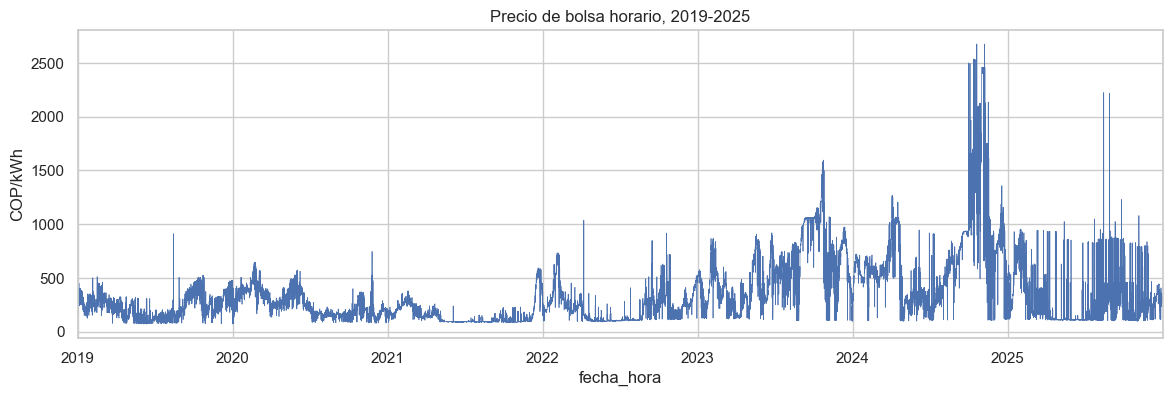

In [7]:
# --- Celda E: Serie completa ---
fig, ax = plt.subplots(figsize=(14, 4))
df_precio["precio_bolsa_cop_kwh"].plot(ax=ax, linewidth=0.5)
ax.set_title("Precio de bolsa horario, 2019-2025")
ax.set_ylabel("COP/kWh")
plt.show()

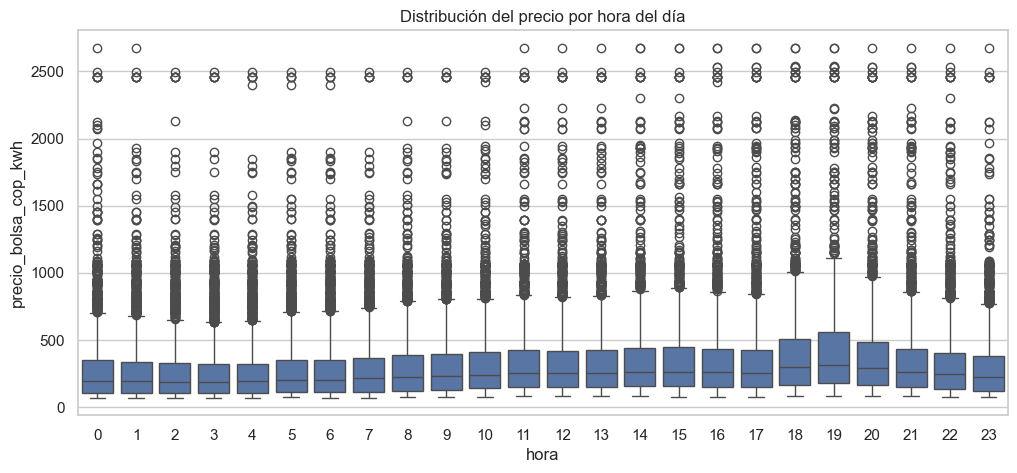

In [8]:
# --- Celda F: Estacionalidad diaria (hora del día) ---
df_precio["hora"] = df_precio.index.hour
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_precio, x="hora", y="precio_bolsa_cop_kwh", ax=ax)
ax.set_title("Distribución del precio por hora del día")
plt.show()

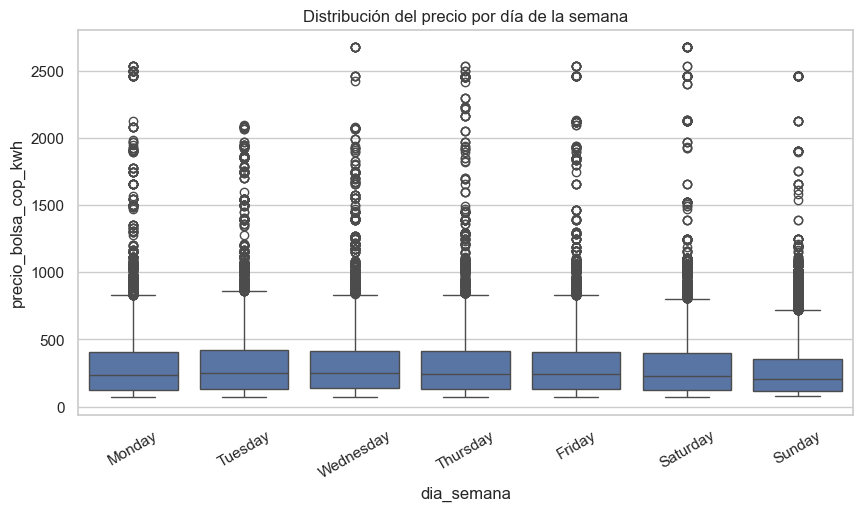

In [9]:
# --- Celda G: Estacionalidad semanal ---
df_precio["dia_semana"] = df_precio.index.day_name()
orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_precio, x="dia_semana", y="precio_bolsa_cop_kwh", order=orden_dias, ax=ax)
ax.set_title("Distribución del precio por día de la semana")
plt.xticks(rotation=30)
plt.show()

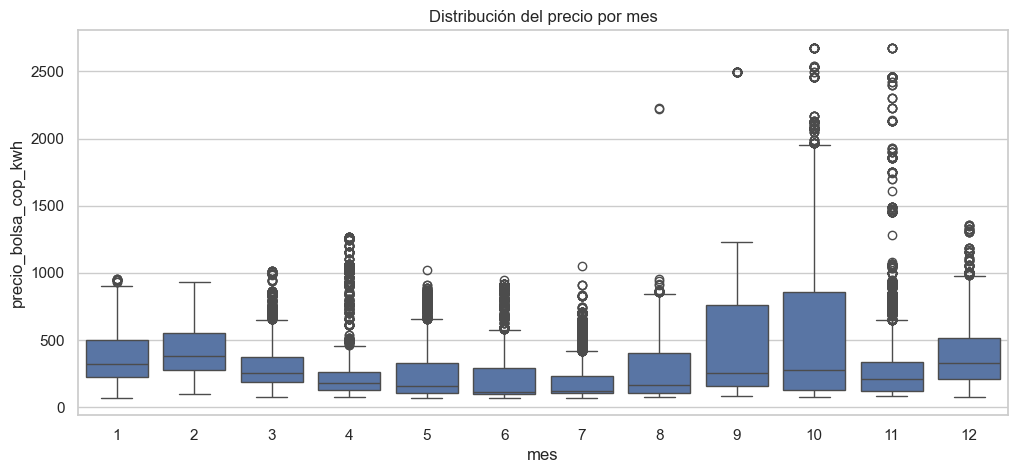

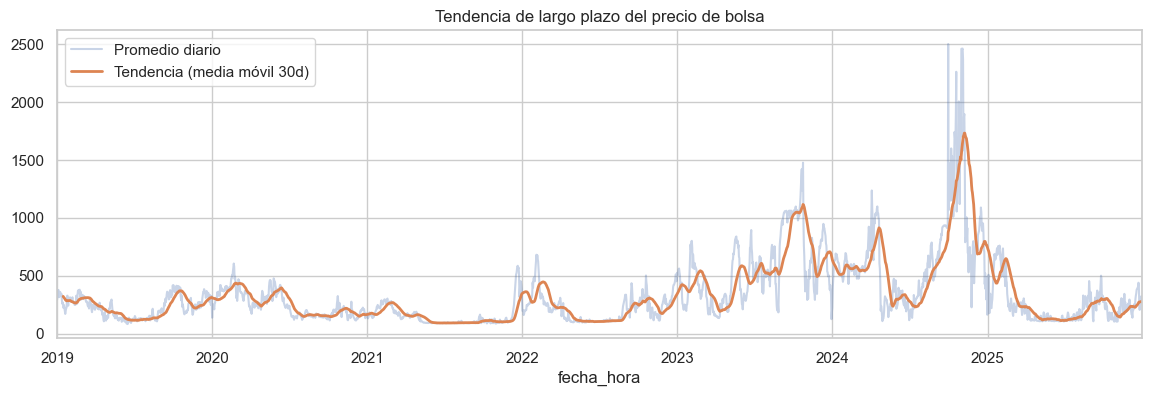

In [10]:
# --- Celda H: Estacionalidad anual + tendencia de largo plazo ---
df_precio["mes"] = df_precio.index.month
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_precio, x="mes", y="precio_bolsa_cop_kwh", ax=ax)
ax.set_title("Distribución del precio por mes")
plt.show()

# Tendencia: media móvil de 30 días sobre el promedio diario
precio_diario = df_precio["precio_bolsa_cop_kwh"].resample("D").mean()
tendencia_30d = precio_diario.rolling(window=30, min_periods=15).mean()

fig, ax = plt.subplots(figsize=(14, 4))
precio_diario.plot(ax=ax, alpha=0.3, label="Promedio diario")
tendencia_30d.plot(ax=ax, linewidth=2, label="Tendencia (media móvil 30d)")
ax.legend()
ax.set_title("Tendencia de largo plazo del precio de bolsa")
plt.show()

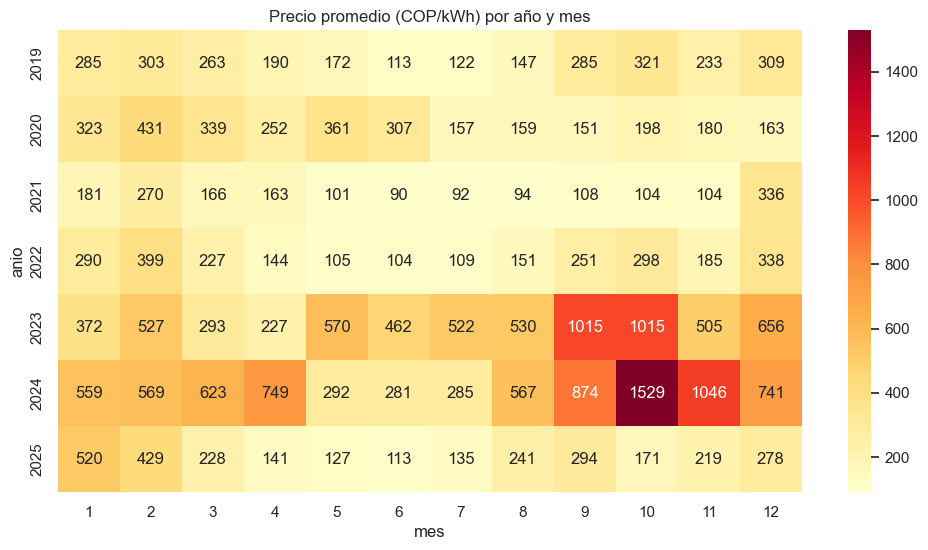

mes,1,2,3,4,5,6,7,8,9,10,11,12
anio,,,,,,,,,,,,
2019,285.423669,303.470307,262.857917,189.792971,172.127131,113.283558,122.331322,147.257976,284.756475,321.287089,232.893463,308.509040
2020,323.055756,430.516455,339.491556,252.159121,360.984392,306.584126,156.877409,158.966011,150.940450,198.312243,179.971315,163.224878
2021,181.257874,270.127288,165.904888,162.631072,100.533253,90.425137,91.719774,93.619044,108.017922,103.754009,104.174865,335.943710
2022,289.918867,399.164648,227.000176,143.794786,105.489739,104.145293,109.398460,150.886291,251.065399,298.067139,184.535923,338.084401
2023,371.981315,526.685958,293.495412,226.957297,569.688989,462.193001,521.645536,529.824464,1014.986097,1015.439869,504.549910,656.191260
2024,558.722196,568.706088,622.773568,748.656762,291.549853,280.697362,285.092811,567.417756,873.706954,1529.135664,1046.433431,741.004156
2025,519.660148,428.731653,228.481563,140.628170,126.699424,112.508910,134.933115,241.390583,293.743395,170.904948,218.999392,278.467446


In [11]:
# --- Celda I: Precio promedio por año y mes (heatmap) ---
# Con pivot_table separamos el precio promedio de cada combinación año-mes.
# Esto es justo lo que el boxplot de la Celda H no permitía ver: si septiembre
# es alto SOLO en 2023-2024, o si es alto en la mayoría de los años.
df_precio["anio"] = df_precio.index.year

tabla_anio_mes = df_precio.pivot_table(
    values="precio_bolsa_cop_kwh",
    index="anio",
    columns="mes",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(tabla_anio_mes, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
ax.set_title("Precio promedio (COP/kWh) por año y mes")
plt.show()

tabla_anio_mes

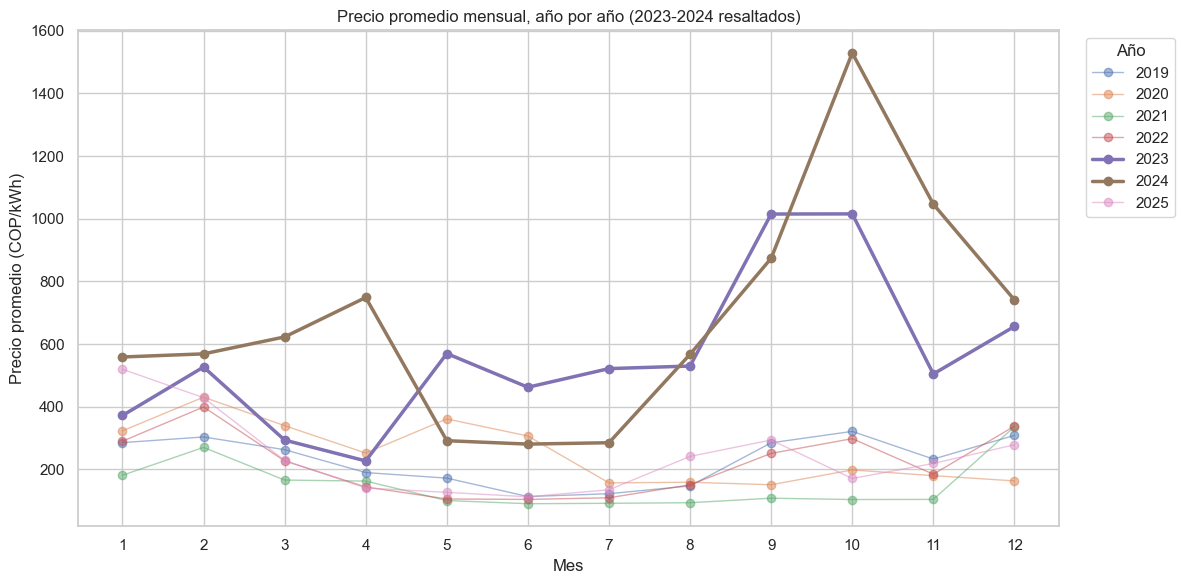

In [12]:
# --- Celda J: Comparación año por año, mes a mes (líneas) ---
# Resaltamos 2023 y 2024 (los años del evento) para que salten a la vista
# frente al resto — si el resto de años se ve relativamente plano en
# sep-oct-nov, la hipótesis del evento se confirma.
fig, ax = plt.subplots(figsize=(12, 6))
for anio in tabla_anio_mes.index:
    resaltar = anio in [2023, 2024]
    ax.plot(
        tabla_anio_mes.columns,
        tabla_anio_mes.loc[anio],
        marker="o",
        linewidth=2.5 if resaltar else 1,
        alpha=1.0 if resaltar else 0.5,
        label=str(anio)
    )

ax.set_xlabel("Mes")
ax.set_ylabel("Precio promedio (COP/kWh)")
ax.set_title("Precio promedio mensual, año por año (2023-2024 resaltados)")
ax.set_xticks(range(1, 13))
ax.legend(title="Año", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
# --- Celda K: Cargar el índice ONI (mensual) ---
# data/external/oni_index.csv se llenó a mano desde la tabla oficial de
# https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/oni/v6/
# (ONI, ERSSTv6 -- consultado 6 de agosto de 2026, anótalo para la memoria final)

ruta_oni = RAIZ / "data" / "external" / "oni_index.csv"
oni_ancho = pd.read_csv(ruta_oni)

columnas_temporada = ["DJF","JFM","FMA","MAM","AMJ","MJJ","JJA","JAS","ASO","SON","OND","NDJ"]
mes_central = {temp: i + 1 for i, temp in enumerate(columnas_temporada)}  # DJF->1 ... NDJ->12

# Ancho (un año por fila) -> largo (una fila por año-mes), para poder unirlo
# después por (anio, mes) igual que ya haces con las demás variables
oni_largo = oni_ancho.melt(id_vars="anio", value_vars=columnas_temporada,
                            var_name="temporada", value_name="oni")
oni_largo["mes"] = oni_largo["temporada"].map(mes_central)
oni_largo = oni_largo[["anio", "mes", "oni"]].sort_values(["anio", "mes"]).reset_index(drop=True)
oni_largo.head(15)

,anio,mes,oni
0,2019,1,1.0
1,2019,2,0.9
2,2019,3,0.9
3,2019,4,0.8
4,2019,5,0.7
5,2019,6,0.6
6,2019,7,0.4
7,2019,8,0.2
8,2019,9,0.3
9,2019,10,0.5


In [14]:
# --- Celda L: Unir ONI al dataframe de precio, por año-mes ---
# ONI es mensual, precio es horario: mismo criterio de upsampling (Opción A)
# que ya acordaron para embalses y aportes -- se repite el valor del mes en
# todas sus horas, no se degrada el precio a mensual.
df_precio = df_precio.merge(oni_largo, on=["anio", "mes"], how="left")

print("Nulos en oni tras el merge:", df_precio["oni"].isna().sum())  # debería ser 0 si la tabla cubre 2019-2025 completo
df_precio[["oni"]].describe()

Nulos en oni tras el merge: 0


,oni
count,61368.000000
mean,-0.007118
std,0.780435
min,-1.100000
25%,-0.700000
50%,-0.200000
75%,0.600000
max,2.000000


In [15]:
# --- Celda M: Cierre del Paso 1.3 ---
print("Paso 1.3 completo para la serie de precio:")
print(f"- Indicador de pandemia: {df_precio['es_pandemia'].sum() if 'es_pandemia' in df_precio.columns else 'pendiente de traer de 02_datos_embalses_hidrologia'} horas marcadas")
print(f"- ONI: rango {df_precio['oni'].min()} a {df_precio['oni'].max()}, 0 nulos")

Paso 1.3 completo para la serie de precio:
- Indicador de pandemia: pendiente de traer de 02_datos_embalses_hidrologia horas marcadas
- ONI: rango -1.1 a 2.0, 0 nulos


In [16]:
# --- Celda de arranque: imports + ubicar la raíz del proyecto ---
import pandas as pd
from pathlib import Path

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontré '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
print("Raíz del proyecto:", RAIZ)

Raíz del proyecto: C:\Users\mgdbj\xm-spot-price-predictor


In [17]:
# --- Celda 22 ---
fuentes = {
    "precio":     ("precio_bolsa_2019_2025.csv", "precio_bolsa_cop_kwh"),
    "demanda":    ("demanda_real_2019_2025.csv", "demanda_kwh"),
    "generacion": ("generacion_total_2019_2025.csv", "generacion_kwh"),
    "embalses":   ("volumen_util_embalses_2019_2025.csv", "valor"),
    "aportes":    ("aportes_hidricos_2019_2025.csv", "valor"),
}

datos = {}
for nombre, (archivo, col_valor) in fuentes.items():
    ruta = RAIZ / "data" / archivo
    df = pd.read_csv(ruta, encoding="utf-8-sig")
    es_horaria = col_valor in ("precio_bolsa_cop_kwh", "demanda_kwh", "generacion_kwh")
    col_fecha = "fecha_hora" if es_horaria else "fecha"
    df = df.rename(columns={df.columns[0]: col_fecha})
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    datos[nombre] = df

print("Celda 22 OK:", {k: v.shape for k, v in datos.items()})

Celda 22 OK: {'precio': (61368, 2), 'demanda': (61368, 2), 'generacion': (61368, 2), 'embalses': (2557, 2), 'aportes': (2557, 2)}


In [18]:
# --- Celda 23 (CORREGIDA: interpolacion en vez de ffill -- ver bitacora 2026-09-03 15:16 del README) ---
precio_h     = datos["precio"].rename(columns={"precio_bolsa_cop_kwh": "precio_bolsa"})[["fecha_hora", "precio_bolsa"]]
demanda_h    = datos["demanda"].rename(columns={"demanda_kwh": "demanda"})[["fecha_hora", "demanda"]]
generacion_h = datos["generacion"].rename(columns={"generacion_kwh": "generacion"})[["fecha_hora", "generacion"]]

indice_horario = pd.DatetimeIndex(precio_h["fecha_hora"])

def expandir_diaria_a_horaria(df, col_fecha, col_valor, nombre_final):
    """Interpolacion lineal en vez de ffill (escalon). Segura frente a fuga de datos porque el
    pipeline de features (05) siempre rezaga esta columna 24h o mas -- el hueco de interpolacion
    (~24h) queda cubierto por ese rezago, igual que se explico para ARX+GARCH en la sesion."""
    serie = df.set_index(col_fecha)[col_valor].sort_index()
    serie = serie[~serie.index.duplicated(keep="first")]
    serie_horaria = serie.reindex(indice_horario).interpolate(method="linear", limit_direction="both")
    return serie_horaria.rename(nombre_final).rename_axis("fecha_hora").reset_index()

embalses_horario = expandir_diaria_a_horaria(datos["embalses"], "fecha", "valor", "volumen_embalses")
aportes_horario  = expandir_diaria_a_horaria(datos["aportes"],  "fecha", "valor", "aportes_hidricos")

df_maestro = (precio_h
    .merge(demanda_h, on="fecha_hora", how="left")
    .merge(generacion_h, on="fecha_hora", how="left")
    .merge(embalses_horario, on="fecha_hora", how="left")
    .merge(aportes_horario, on="fecha_hora", how="left")
    .sort_values("fecha_hora")
    .reset_index(drop=True))

print("Celda 23 OK:", df_maestro.shape)


Celda 23 OK: (61368, 6)


In [19]:
# --- Celda 24 (CORREGIDA: rampa causal de ONI en vez de escalon mensual) ---
df_maestro["es_pandemia"] = (
    (df_maestro["fecha_hora"] >= "2020-03-25") & (df_maestro["fecha_hora"] <= "2020-08-31")
).astype(int)

def construir_oni_horario_causal(indice_ref, ruta_oni):
    """ONI con rampa causal: dentro de cada mes, sube/baja linealmente desde el valor OFICIAL del
    mes anterior hasta el del mes actual, llegando a este ultimo justo al final del mes. Nunca usa
    el dato del mes siguiente (a diferencia de una interpolacion real), por eso es segura sin
    importar el horizonte de pronostico."""
    oni_ancho = pd.read_csv(ruta_oni)
    columnas_temporada = ["DJF","JFM","FMA","MAM","AMJ","MJJ","JJA","JAS","ASO","SON","OND","NDJ"]
    mes_central = {temp: i + 1 for i, temp in enumerate(columnas_temporada)}
    oni_largo = oni_ancho.melt(id_vars="anio", value_vars=columnas_temporada, var_name="temporada", value_name="oni")
    oni_largo["mes"] = oni_largo["temporada"].map(mes_central)
    oni_largo = oni_largo[["anio", "mes", "oni"]].sort_values(["anio", "mes"]).reset_index(drop=True)
    oni_largo["oni_mes_anterior"] = oni_largo["oni"].shift(1)
    oni_largo["oni_mes_anterior"] = oni_largo["oni_mes_anterior"].fillna(oni_largo["oni"])

    df_horas = pd.DataFrame({"fecha_hora": indice_ref})
    df_horas["anio"] = df_horas["fecha_hora"].dt.year
    df_horas["mes"] = df_horas["fecha_hora"].dt.month
    df_horas = df_horas.merge(oni_largo[["anio", "mes", "oni", "oni_mes_anterior"]], on=["anio", "mes"], how="left")

    inicio_mes = df_horas["fecha_hora"].values.astype("datetime64[M]").astype("datetime64[ns]")
    horas_desde_inicio_mes = (df_horas["fecha_hora"] - inicio_mes) / pd.Timedelta(hours=1)
    horas_totales_mes = df_horas["fecha_hora"].dt.days_in_month * 24
    fraccion = (horas_desde_inicio_mes / horas_totales_mes).clip(0, 1)

    df_horas["oni"] = df_horas["oni_mes_anterior"] + fraccion * (df_horas["oni"] - df_horas["oni_mes_anterior"])
    return df_horas[["fecha_hora", "oni"]]

ruta_oni = RAIZ / "data" / "external" / "oni_index.csv"
oni_horario = construir_oni_horario_causal(indice_horario, ruta_oni)
df_maestro = df_maestro.merge(oni_horario, on="fecha_hora", how="left")

print("Dataset maestro final:", df_maestro.shape)
print(df_maestro.isna().sum())

df_maestro.to_csv(RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv", index=False)
print("Guardado en data/processed/dataset_maestro_2019_2025.csv")


Dataset maestro final: (61368, 8)
fecha_hora          0
precio_bolsa        0
demanda             0
generacion          0
volumen_embalses    0
aportes_hidricos    0
es_pandemia         0
oni                 0
dtype: int64


Guardado en data/processed/dataset_maestro_2019_2025.csv


A PARTIR DE AQUI MOMENTO SEÑALES Y SISTEMAS 

In [20]:
# --- Celda N: Verificar estado antes de seguir ---
try:
    print(df_precio.shape)
    print(df_precio.index.min(), "a", df_precio.index.max())
except NameError:
    print("df_precio no existe en esta sesión -- vuelve a correr las Celdas A y B de antes de continuar.")

(61368, 6)
0 a 61367


In [21]:
# --- Celda A: Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [22]:
# --- Celda B: Cargar y preparar el precio de bolsa ---
ruta = RAIZ / "data" / "precio_bolsa_2019_2025.csv"
df_precio = pd.read_csv(ruta)

df_precio["fecha_hora"] = pd.to_datetime(df_precio["fecha_hora"], format="%Y-%m-%d %H:%M:%S")
df_precio = df_precio.sort_values("fecha_hora").reset_index(drop=True)
df_precio = df_precio.set_index("fecha_hora")
df_precio.head()

,precio_bolsa_cop_kwh
fecha_hora,
2019-01-01 00:00:00,318.4231
2019-01-01 01:00:00,318.4231
2019-01-01 02:00:00,318.4231
2019-01-01 03:00:00,318.4231
2019-01-01 04:00:00,308.9231


In [23]:
# --- Celda O: Periodograma de la serie original ---
import numpy as np
from scipy import signal  # scipy no depende de la versión de pandas -- sin conflictos conocidos
                           # (si da ModuleNotFoundError, corre: pip install scipy --break-system-packages)

fs = 1.0  # 1 muestra por hora -> la frecuencia queda en ciclos/hora, y 1/frecuencia da el período en horas directamente

frecuencias, potencia = signal.periodogram(
    df_precio["precio_bolsa_cop_kwh"].values,
    fs=fs,
    detrend="constant"  # solo resta la media -- la tendencia la tratamos aparte, a propósito, en la próxima celda
)

periodo_horas = np.divide(1, frecuencias, out=np.full_like(frecuencias, np.inf), where=frecuencias != 0)

In [24]:
# --- Celda P: Mismo periodograma, pero sobre la serie sin tendencia ---
ventana_horas = 30 * 24  # equivalente a la media móvil de 30 días de la Celda H, calculada directo en horas
tendencia_horaria = df_precio["precio_bolsa_cop_kwh"].rolling(
    window=ventana_horas, min_periods=ventana_horas // 2, center=True
).mean()

residuo = (df_precio["precio_bolsa_cop_kwh"] - tendencia_horaria).dropna()  # center=True deja NaN en los bordes (~15 días)

frecuencias_r, potencia_r = signal.periodogram(residuo.values, fs=fs, detrend="constant")
periodo_horas_r = np.divide(1, frecuencias_r, out=np.full_like(frecuencias_r, np.inf), where=frecuencias_r != 0)

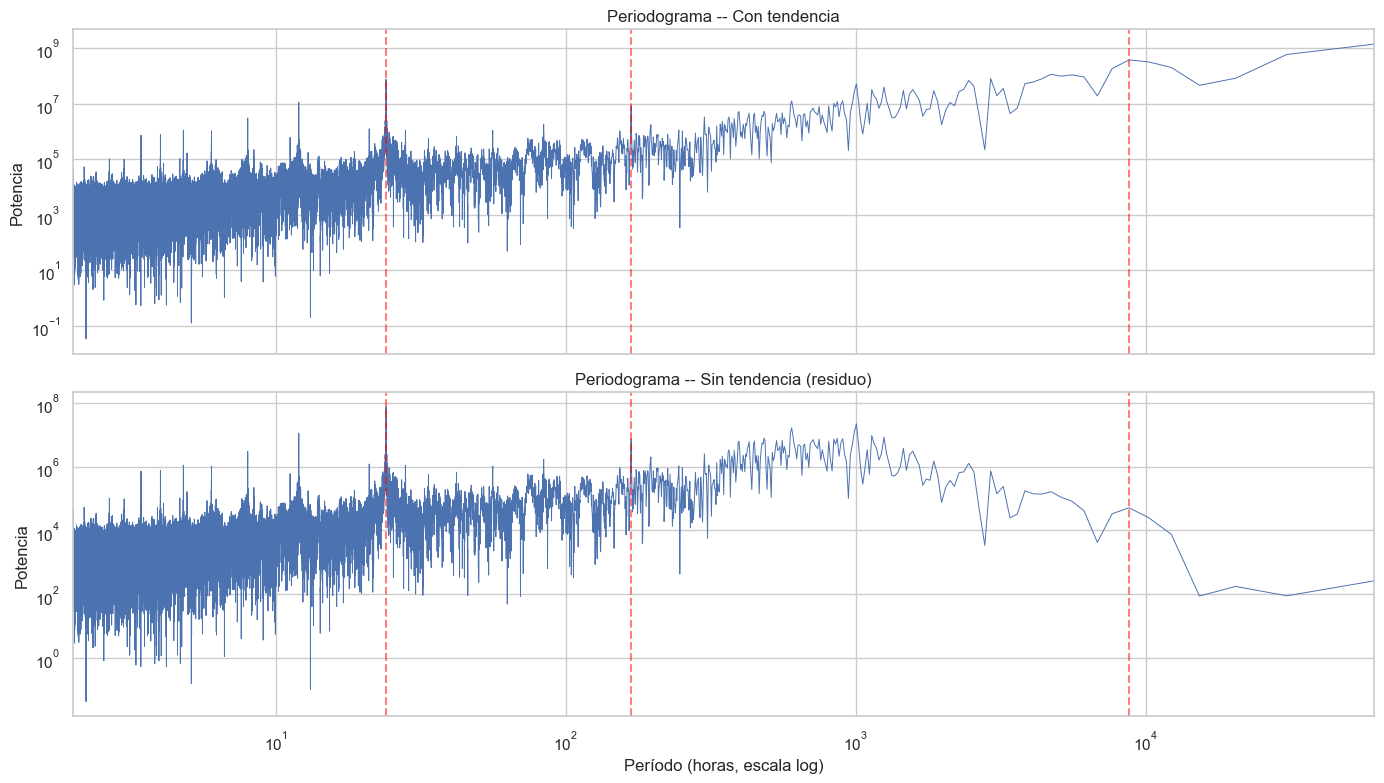

In [25]:
# --- Celda Q (corregida) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, periodo, pot, titulo in [
    (axes[0], periodo_horas, potencia, "Con tendencia"),
    (axes[1], periodo_horas_r, potencia_r, "Sin tendencia (residuo)"),
]:
    ax.plot(periodo, pot, linewidth=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Potencia")
    ax.set_title(f"Periodograma -- {titulo}")
    for h, etiqueta in [(24, "24h"), (168, "168h (7d)"), (8766, "~1 año")]:
        ax.axvline(h, color="red", linestyle="--", alpha=0.5)

axes[1].set_xlabel("Período (horas, escala log)")
axes[1].set_xlim(2, periodo_horas[np.isfinite(periodo_horas)].max())  # excluye el inf antes de tomar el máximo
plt.tight_layout()
plt.show()

## Paso 1.5b -- Comparacion de filtros: promedio movil vs. Savitzky-Golay

Pendiente de la Fase 1 del Anexo 1 ("comparar filtros: promedio movil vs. Savitzky-Golay").
La Celda P de arriba ya usa un promedio movil de 30 dias para separar tendencia de residuo antes
del periodograma. Aqui se agrega Savitzky-Golay como alternativa y se comparan ambas.

Diferencia conceptual: el promedio movil es un filtro FIR de pesos uniformes -- cada punto de la
tendencia es el promedio simple de la ventana. Savitzky-Golay, en cambio, ajusta un polinomio local
(por minimos cuadrados) dentro de cada ventana y usa el valor del polinomio en el centro. Consecuencia
practica: el promedio movil tiende a "achatar" picos y reaccionar con retraso a cambios bruscos;
Savitzky-Golay sigue mejor la curvatura local y reacciona mas rapido, a costa de dejar pasar algo
mas de ruido de alta frecuencia si el orden del polinomio es alto.

In [26]:
# --- Dos tendencias sobre la misma serie horaria: promedio movil (ya calculado) vs. Savitzky-Golay ---
from scipy.signal import savgol_filter

ventana_horas_sg = ventana_horas + 1 if ventana_horas % 2 == 0 else ventana_horas  # savgol exige ventana impar
orden_polinomio = 3

tendencia_sg = pd.Series(
    savgol_filter(df_precio["precio_bolsa_cop_kwh"].values, window_length=ventana_horas_sg, polyorder=orden_polinomio),
    index=df_precio.index,
    name="tendencia_savgol",
)

print(f"Ventana: {ventana_horas_sg} horas (~{ventana_horas_sg/24:.0f} dias) | Orden del polinomio: {orden_polinomio}")
print("Tendencia Savitzky-Golay calculada sobre toda la serie horaria (sin el hueco en los bordes que deja el promedio movil centrado).")


Ventana: 721 horas (~30 dias) | Orden del polinomio: 3
Tendencia Savitzky-Golay calculada sobre toda la serie horaria (sin el hueco en los bordes que deja el promedio movil centrado).


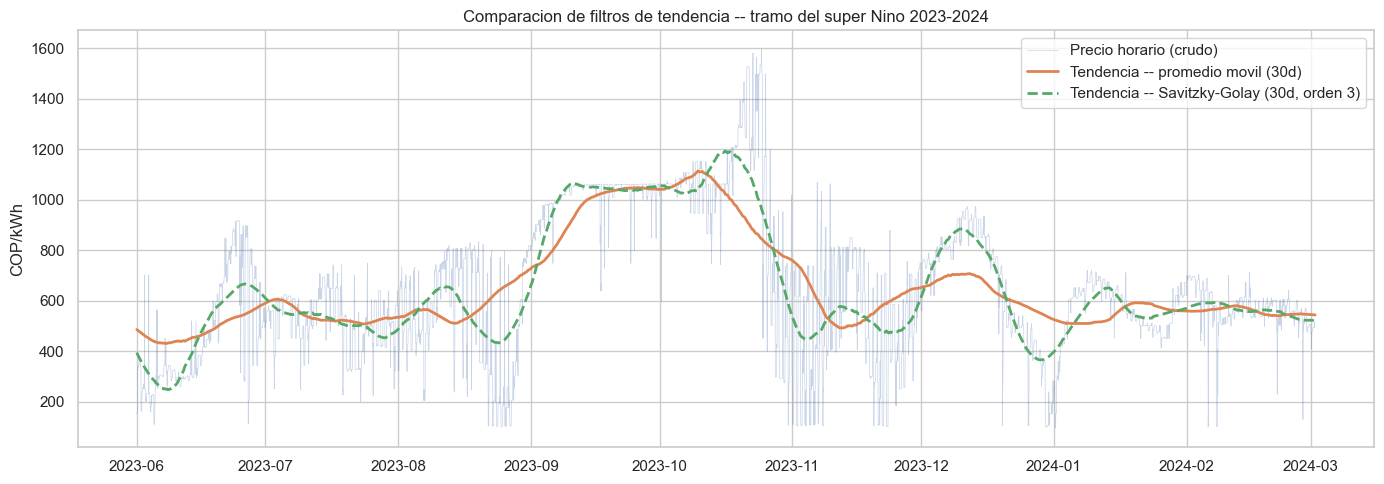

In [27]:
# --- Comparacion visual: zoom al tramo del super Nino 2023-2024, donde el precio sube mas rapido ---
# Es la ventana mas dura para un filtro de tendencia -- un cambio real y rapido, no ruido -- por eso
# es el mejor lugar para ver cual de los dos filtros sigue el cambio mas fiel y con menos retraso.
ventana_zoom = slice("2023-06-01", "2024-03-01")

precio_zoom = df_precio["precio_bolsa_cop_kwh"].loc[ventana_zoom]
tendencia_ma_zoom = tendencia_horaria.loc[ventana_zoom]
tendencia_sg_zoom = tendencia_sg.loc[ventana_zoom]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(precio_zoom.index, precio_zoom.values,
        alpha=0.3, linewidth=0.5, label="Precio horario (crudo)")
ax.plot(tendencia_ma_zoom.index, tendencia_ma_zoom.values,
        linewidth=2, label="Tendencia -- promedio movil (30d)")
ax.plot(tendencia_sg_zoom.index, tendencia_sg_zoom.values,
        linewidth=2, label="Tendencia -- Savitzky-Golay (30d, orden 3)", linestyle="--")
ax.set_title("Comparacion de filtros de tendencia -- tramo del super Nino 2023-2024")
ax.set_ylabel("COP/kWh")
ax.legend()
plt.tight_layout()
plt.show()


In [28]:
# --- Comparacion cuantitativa: retraso frente a un cambio real, y ruido residual ---
# Retraso: en el pico de subida mas pronunciada del tramo de zoom, cuanto tarda cada filtro en
# alcanzar el 90% del cambio real, medido en horas desde que el precio crudo ya lo alcanzo.
sub_zoom = df_precio["precio_bolsa_cop_kwh"].loc[ventana_zoom]
idx_pico = sub_zoom.idxmax()

nivel_previo = sub_zoom.loc[:idx_pico - pd.Timedelta(days=45)].mean()
nivel_pico = sub_zoom.loc[idx_pico - pd.Timedelta(days=3): idx_pico + pd.Timedelta(days=3)].mean()
umbral_90 = nivel_previo + 0.9 * (nivel_pico - nivel_previo)

def horas_hasta_umbral(serie_tendencia, inicio, umbral):
    tramo = serie_tendencia.loc[inicio:]
    cruce = tramo[tramo >= umbral]
    if len(cruce) == 0:
        return None
    return (cruce.index[0] - inicio).total_seconds() / 3600

inicio_subida = idx_pico - pd.Timedelta(days=60)
retraso_ma = horas_hasta_umbral(tendencia_horaria, inicio_subida, umbral_90)
retraso_sg = horas_hasta_umbral(tendencia_sg, inicio_subida, umbral_90)

print(f"Nivel previo (calmado): {nivel_previo:.1f} COP/kWh | Nivel del pico: {nivel_pico:.1f} COP/kWh | Umbral 90%: {umbral_90:.1f}")
print(f"Horas hasta alcanzar el 90% de la subida -- Promedio movil: {retraso_ma}h  |  Savitzky-Golay: {retraso_sg}h")
if retraso_sg is not None and retraso_ma is not None:
    print(f"Savitzky-Golay llega {(retraso_ma - retraso_sg):.0f}h antes que el promedio movil")

residuo_ma = (df_precio["precio_bolsa_cop_kwh"] - tendencia_horaria).dropna()
residuo_sg = (df_precio["precio_bolsa_cop_kwh"] - tendencia_sg).dropna()
print()
print(f"Desviacion estandar del residuo -- Promedio movil: {residuo_ma.std():.2f}  |  Savitzky-Golay: {residuo_sg.std():.2f}")


Nivel previo (calmado): 544.3 COP/kWh | Nivel del pico: 1102.9 COP/kWh | Umbral 90%: 1047.0
Horas hasta alcanzar el 90% de la subida -- Promedio movil: 724.0h  |  Savitzky-Golay: 348.0h
Savitzky-Golay llega 376h antes que el promedio movil

Desviacion estandar del residuo -- Promedio movil: 136.34  |  Savitzky-Golay: 115.86


**Conclusion del punto de filtros:** Savitzky-Golay seria preferible como filtro de tendencia si
lo que importa es reaccionar rapido a cambios reales (como el arranque de un evento El Nino) sin
introducir retraso artificial. El promedio movil es mas simple y mas facil de explicar, pero paga
ese retraso. Para el proposito actual (restar la tendencia antes del periodograma, donde el objetivo
es solo "sacar" la componente de baja frecuencia, no seguirla con precision), la eleccion importa
menos; para un futuro modulo que necesite detectar el INICIO de un cambio de regimen en tiempo real,
Savitzky-Golay es la opcion mas defendible de las dos.

## Paso 1.5c -- Correlacion precio-hidrologia-demanda

Pendiente de la Fase 1 del Anexo 1. Se calcula sobre el dataset maestro completo (2019-2025,
resolucion horaria) para ver que tan relacionadas estan las variables entre si -- sin rezagar nada
todavia, porque este es un analisis EXPLORATORIO/descriptivo de la Fase 1, no una feature para el
modelo (eso ya se maneja aparte, con el cuidado de fuga de datos, en `05_features_compartidas_juan.ipynb`).

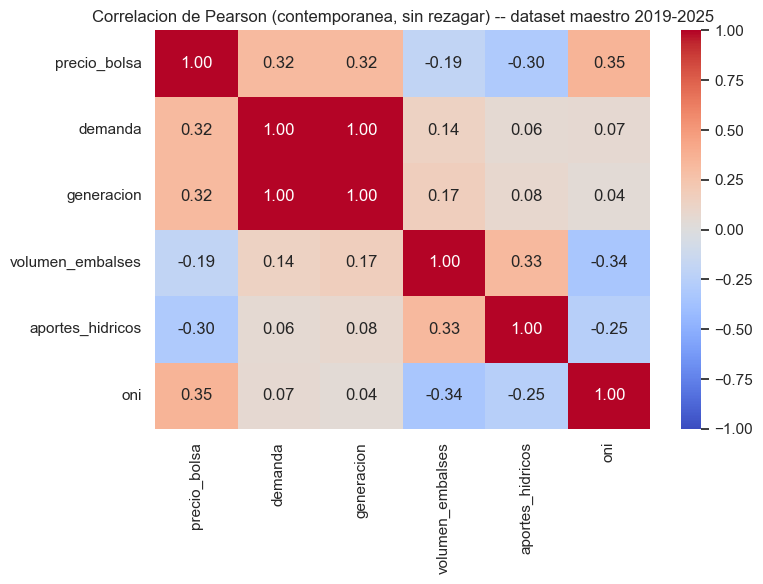

precio_bolsa        1.000000
oni                 0.354909
demanda             0.320201
generacion          0.318425
volumen_embalses   -0.189245
aportes_hidricos   -0.301753
Name: precio_bolsa, dtype: float64

In [29]:
# --- Correlacion contemporanea entre las 6 variables del dataset maestro ---
df_correlacion = pd.read_csv(
    RAIZ / "data" / "processed" / "dataset_maestro_2019_2025.csv",
    parse_dates=["fecha_hora"],
    usecols=["fecha_hora", "precio_bolsa", "demanda", "generacion", "volumen_embalses", "aportes_hidricos", "oni"],
)

matriz_correlacion = df_correlacion.drop(columns="fecha_hora").corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlacion de Pearson (contemporanea, sin rezagar) -- dataset maestro 2019-2025")
plt.tight_layout()
plt.show()

matriz_correlacion["precio_bolsa"].sort_values(ascending=False)


In [30]:
# --- Correlacion cruzada con rezago: en que momento la hidrologia se relaciona MAS con el precio ---
# La correlacion contemporanea de la celda anterior no distingue si el efecto es inmediato o
# retardado. Aqui se corre precio contra volumen_embalses y aportes_hidricos en varios rezagos
# (0h, 24h, 7d, 30d) para ver en que horizonte la relacion es mas fuerte -- esto es, en esencia,
# la justificacion empirica de por que las features usan rezagos de 24h en vez de valores crudos.
rezagos_horas = [0, 24, 24 * 7, 24 * 30]

resultados_ccf = []
for variable in ["volumen_embalses", "aportes_hidricos"]:
    for rezago in rezagos_horas:
        serie_rezagada = df_correlacion[variable].shift(rezago)
        corr = df_correlacion["precio_bolsa"].corr(serie_rezagada)
        resultados_ccf.append({"variable": variable, "rezago_horas": rezago, "correlacion_con_precio": corr})

df_ccf = pd.DataFrame(resultados_ccf)
tabla_ccf = df_ccf.pivot(index="rezago_horas", columns="variable", values="correlacion_con_precio").round(3)
tabla_ccf


variable,aportes_hidricos,volumen_embalses
rezago_horas,,
0,-0.302,-0.189
24,-0.317,-0.186
168,-0.326,-0.157
720,-0.202,-0.057


**Conclusion del punto de correlacion:** ver los numeros de la celda anterior tras ejecutar --
si la correlacion con `volumen_embalses`/`aportes_hidricos` es mas fuerte (en magnitud) en algun
rezago mayor a 0h, eso respalda empiricamente por que el pipeline de features usa esas variables
rezagadas 24h en vez de en su valor del mismo instante (ademas del motivo de fuga de datos ya
documentado).